## **Imports**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import mannwhitneyu


## **Introduction**

The goal of this project is to analyze an A/B test and understand how the new feature affects user behavior.

We compare two groups (A and B) and look at key metrics such as conversion, retention, and revenue.

The main goal is to understand whether the changes improve performance and whether there are any risks.

## **Business Goal**

The primary goal of this experiment is to determine whether the new feature improves user conversion and overall business performance.

Specifically, we aim to understand:
- Does the feature increase user activation?
- Does it affect retention?
- Does it lead to higher or lower revenue?

## **Metrics**

We evaluate the experiment using the following key metrics:

- Activation Rate: share of users who completed activation
- Paid Conversion: share of users who made a purchase
- ARPU (Average Revenue per User): average revenue across all users
- ARPPU (Average Revenue per Paying User): average revenue among paying users
- Retention Rate (7-day): share of users who returned after 7 days

## **Data Description**
This dataset contains user-level data generated for an A/B test experiment.

Each row represents a single user and includes information about group assignment (A or B), user characteristics (device, country, age), and behavioral metrics.

Key metrics include:
- activation (whether the user activated the product),
- time to activate,
- revenue within 7 days,
- retention on day 7.

The data is synthetically generated to simulate realistic user behavior and differences between control and treatment groups.

In [2]:
np.random.seed(42)

n = 5000

# групи
groups = np.random.choice(['A', 'B'], size=n)

# user_id
user_id = np.arange(1, n+1)

# device
devices = np.random.choice(['ios', 'android', 'web'], size=n, p=[0.4, 0.4, 0.2])

# country
countries = np.random.choice(['US', 'UK', 'DE', 'FR'], size=n)

# age
age = np.random.normal(30, 8, size=n).astype(int)
age = np.clip(age, 18, 65)

# sessions
sessions = np.random.poisson(3, size=n)

# activation probability
activated = []
for g in groups:
    if g == 'A':
        activated.append(np.random.binomial(1, 0.10))
    else:
        activated.append(np.random.binomial(1, 0.13))

activated = np.array(activated)

# time to activate
time_to_activate = np.where(
    activated == 1,
    np.random.exponential(scale=10, size=n),
    np.nan
)
# revenue (skewed)
revenue = []

for g, a in zip(groups, activated):
    if a == 1:
        # не всі активовані платять
        if g == 'A':
            is_paid = np.random.binomial(1, 0.38)
        else:
            is_paid = np.random.binomial(1, 0.39)
        if is_paid == 1:
            if g == 'A':
                revenue.append(np.random.exponential(scale=52))
            else:
                revenue.append(np.random.exponential(scale=50))
        else:
            revenue.append(0)
    else:
        revenue.append(0)

revenue = np.array(revenue)

# retention
retained = []
for g in groups:
    if g == 'A':
        retained.append(np.random.binomial(1, 0.30))
    else:
        retained.append(np.random.binomial(1, 0.28))  # трохи гірше
retained = np.array(retained)

# dataframe
df = pd.DataFrame({
    'user_id': user_id,
    'group': groups,
    'age': age,
    'device': devices,
    'country': countries,
    'sessions_first_7d': sessions,
    'time_to_activate_min': time_to_activate,
    'activated': activated,
    'revenue_7d': revenue,
    'retained_7d': retained
})



In [3]:
df.head()

,user_id,group,age,device,country,sessions_first_7d,time_to_activate_min,activated,revenue_7d,retained_7d
0,1,A,18,web,FR,1,NaN,0,0.0,0
1,2,B,20,android,FR,4,NaN,0,0.0,0
2,3,A,33,android,UK,1,NaN,0,0.0,0
3,4,A,20,web,US,3,NaN,0,0.0,0
4,5,A,38,ios,US,4,NaN,0,0.0,0


## **Data Quality**
Data quality checks were performed before the analysis.

The dataset contains 5000 observations with no missing values or duplicates. Data types are correct, with numerical and categorical variables properly defined.

The distribution of users between groups A and B is balanced, which allows for a fair comparison of the experiment results.

We also checked the logical consistency of the data. Metrics do not contain abnormal values, and binary variables ("activated", "retained_7d") are correctly represented as 0/1, which is suitable for analysis.

Overall, the dataset is clean and ready for further analysis.


In [4]:
df.shape

(5000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               5000 non-null   int64  
 1   group                 5000 non-null   object 
 2   age                   5000 non-null   int64  
 3   device                5000 non-null   object 
 4   country               5000 non-null   object 
 5   sessions_first_7d     5000 non-null   int64  
 6   time_to_activate_min  600 non-null    float64
 7   activated             5000 non-null   int64  
 8   revenue_7d            5000 non-null   float64
 9   retained_7d           5000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 390.8+ KB


In [6]:
df.isna().sum()

,0
user_id,0
group,0
age,0
device,0
country,0
sessions_first_7d,0
time_to_activate_min,4400
activated,0
revenue_7d,0
retained_7d,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['group'].value_counts()

,count
group,
A,2504
B,2496


In [9]:
df.describe()

,user_id,age,sessions_first_7d,time_to_activate_min,activated,revenue_7d,retained_7d
count,5000.000000,5000.000000,5000.000000,600.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,29.745400,3.027200,9.596561,0.120000,2.468209,0.287200
std,1443.520003,7.375707,1.728658,9.180934,0.324994,15.253407,0.452501
min,1.000000,18.000000,0.000000,0.025235,0.000000,0.000000,0.000000
25%,1250.750000,24.000000,2.000000,2.800699,0.000000,0.000000,0.000000
50%,2500.500000,29.000000,3.000000,6.790265,0.000000,0.000000,0.000000
75%,3750.250000,35.000000,4.000000,13.811188,0.000000,0.000000,1.000000
max,5000.000000,57.000000,11.000000,56.323020,1.000000,318.284434,1.000000


In [10]:
df.groupby('group')['activated'].mean()*100

,activated
group,
A,10.543131
B,13.461538


## **Descriptive stats**
We analyzed the distribution of key metrics for both groups.

The number of **sessions** in the first 7 days has a stable distribution in both groups. The mean is close to the median, so it is reasonable to use the average value.

The **time to activation** is right-skewed in both groups. Most users activate within 6–7 minutes, but some users take much longer, which increases the average. In group B, the median is slightly higher, which may indicate a small delay in activation. However, overall distributions look similar between groups.

We observe higher **activation** in group B (12.45%) compared to group A (10.54%), which needs to be tested for statistical significance.

**Revenue** distribution is right-skewed. The 25th, 50th, and 75th percentiles are equal to 0, while the mean is around equal in both groups. This means that most users do not generate revenue, and only a small group of users generates most of it. Because of this, the mean is not representative. It may be useful to analyze paying users separately.

We also observe lower **retention** in group B (27.28%) compared to group A (30.15%). This may indicate a negative impact of the change on retention and requires further statistical testing.

In [12]:
df.groupby('group')['sessions_first_7d'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2504.0,3.021565,1.738708,0.0,2.0,3.0,4.0,11.0
B,2496.0,3.032853,1.718846,0.0,2.0,3.0,4.0,11.0


In [13]:
df.groupby('group')['time_to_activate_min'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,264.0,9.574242,9.245292,0.025235,2.466955,6.612345,13.965701,45.393631
B,336.0,9.614098,9.143821,0.045109,2.979849,7.134355,13.444524,56.323020


In [14]:
df.groupby('group')['activated'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2504.0,0.105431,0.307170,0.0,0.0,0.0,0.0,1.0
B,2496.0,0.134615,0.341381,0.0,0.0,0.0,0.0,1.0


In [15]:
df.groupby('group')['revenue_7d'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2504.0,2.316521,15.240495,0.0,0.0,0.0,0.0,318.284434
B,2496.0,2.620384,15.267889,0.0,0.0,0.0,0.0,227.949367


In [16]:
df.groupby('group')['retained_7d'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2504.0,0.301518,0.459009,0.0,0.0,0.0,1.0,1.0
B,2496.0,0.272837,0.445507,0.0,0.0,0.0,1.0,1.0


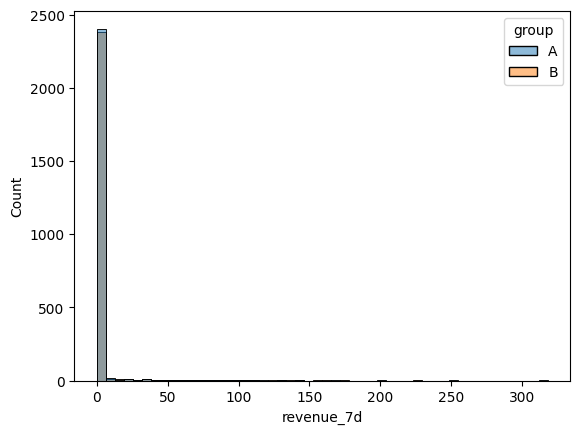

In [17]:
sns.histplot(
    df,
    x='revenue_7d',
    hue='group',
    bins=50
)
plt.show()

Text(0.5, 1.0, ' ')

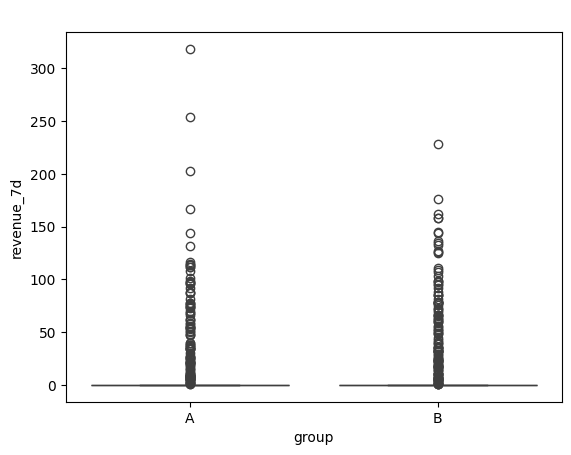

In [18]:
sns.boxplot(
    df,
    x='group',
    y='revenue_7d'
)
plt.title(' ')

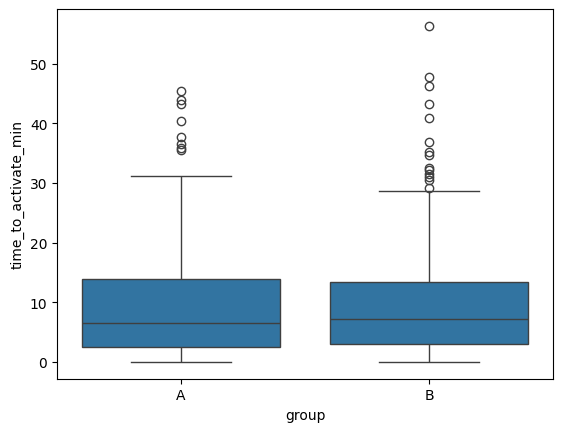

In [19]:
sns.boxplot(
    df,
    x='group',
    y='time_to_activate_min'
)
plt.show()

## **Hypothesis testing**

We test whether the new feature increases user activation.

$H_0$: Activation rate in group B is equal to group A  
$H_1$: Activation rate in group B is higher than in group A  

We use a one-sided z-test for proportions.

In [ ]:
a = 0.05
success_activated_A = df[df['group'] == 'A']['activated'].sum()
success_activated_B = df[df['group'] == 'B']['activated'].sum()
n_activated_A = df[df['group'] == 'A'].shape[0]
n_activated_B = df[df['group'] == 'B'].shape[0]

success_activated = [success_activated_B, success_activated_A]
nobs_activated = [n_activated_B, n_activated_A]

z_stat_activated, p_value_activated = proportions_ztest(
    success_activated,
    nobs_activated,
    alternative='larger')
ci_low_act, ci_high_act = proportion_confint(
    success_activated,
    nobs=nobs_activated,
    alpha=0.05)

print(f'z statistic: {z_stat_activated:.2f}')
print(f'p-value: {p_value_activated:.3f}')

print(f'Group A CI: [{ci_low_act[1]:.3f}, {ci_high_act[1]:.3f}]')
print(f'Group B CI: [{ci_low_act[0]:.3f}, {ci_high_act[0]:.3f}]')

z statistic: 3.18
p-value: 0.001
Group A CI: [0.093, 0.117]
Group B CI: [0.121, 0.148]


#### **Conclusions**

Since the p-value is 0.001, we reject the null hypothesis.

This indicates a statistically significant difference in activation rates between the groups.

The confidence intervals do not overlap, suggesting that the effect size is large.

Group B shows a higher activation rate compared to group A.

# **Hypothesis testing**

We test whether 7-day retention in group B decreased after the change.

H₀: 7-day retention in group B is equal to 7-day retention in group A.  
H₁: 7-day retention in group B is lower than in group A.

Let:
- $p_A$ = true 7-day retention in group A
- $p_B$ = true 7-day retention in group B

Then:

H₀: $p_B$ = $p_A$  
H₁: $p_B$ < $p_A$

We use a one-sided z-test for two proportions.

Significance level: α = 0.05

In [20]:
success_retained_7d_A = df[df['group']=='A']['retained_7d'].sum()
success_retained_7d_B = df[df['group']=='B']['retained_7d'].sum()

n_retained_7d_A = df[df['group']=='A'].shape[0]
n_retained_7d_B = df[df['group']=='B'].shape[0]

success_retained_7d = [success_retained_7d_B, success_retained_7d_A]
nob_retained_7d = [n_retained_7d_B, n_retained_7d_A]

z_stat_retained_7d, p_value_retained_7d = proportions_ztest(
    success_retained_7d,
    nobs=nob_retained_7d,
    alternative='smaller')
ci_low_ret, ci_high_ret = proportion_confint(
    success_retained_7d,
    nobs=nob_retained_7d ,
    alpha=0.05)

print(f'z statistic: {z_stat_retained_7d:.2f}')
print(f'p-value: {p_value_retained_7d:.3f}')

print(f'Group A CI: [{ci_low_ret[1]:.3f}, {ci_high_ret[1]:.3f}]')
print(f'Group B CI: [{ci_low_ret[0]:.3f}, {ci_high_ret[0]:.3f}]')

z statistic: -2.24
p-value: 0.013
Group A CI: [0.284, 0.319]
Group B CI: [0.255, 0.290]


#### **Conclusions**:
Since the p-value is 0.013 and is below the significance level of 0.05,
we reject the null hypothesis.

This indicates a statistically significant decrease in 7-day retention
in group B compared to group A.

Although the confidence intervals show some overlap,
the effect remains statistically significant,
suggesting that the decrease is real but relatively small.

Therefore, the new feature appears to have a negative impact on user retention.

Despite the increase in conversion, this introduces a potential risk
for long-term user engagement.

### Next, we analyze revenue-related metrics to evaluate the overall business impact of the experiment.

In [24]:
df['paid'] = df['revenue_7d'] > 0
df.groupby('group')['paid'].mean()*100

,paid
group,
A,0.0
B,0.0


**Hypothesis testing**

We analyze the share of users who made a purchase to understand whether the change increased the number of paying users.

$H_0$: The share of paying users in group B is equal to that in group A  
$H_1$: The share of paying users in group B is higher than in group A  

Let:

$p_A$ = true share of paying users in group A  
$p_B$ = true share of paying users in group B  

Then:

$H_0$: $p_B$ = $p_A$

$H_1$: $p_B$ > $p_A$  

We use a one-sided z-test for two proportions.

Significance level: α = 0.05

In [23]:
success_paid_A = df[df['group']=='A']['paid'].sum()
success_paid_B = df[df['group']=='B']['paid'].sum()

n_paid_A = df[df['group']=='A'].shape[0]
n_paid_B = df[df['group']=='B'].shape[0]

success_paid = [success_paid_B, success_paid_A]
nob_paid = [n_paid_B, n_paid_A]

z_stat_paid, p_value_paid = proportions_ztest(
    success_paid,
    nobs=nob_paid,
    alternative='larger'
)
ci_low_paid, ci_high_paid = proportion_confint(
    success_paid,
    nobs=nob_paid,
    alpha=0.05)

print(f'z statistic: {z_stat_paid:.2f}')
print(f'p-value: {p_value_paid:.3f}')

print(f'Group A CI: [{ci_low_paid[1]:.3f}, {ci_high_paid[1]:.3f}]')
print(f'Group B CI: [{ci_low_paid[0]:.3f}, {ci_high_paid[0]:.3f}]')

z statistic: 0.96
p-value: 0.170
Group A CI: [0.037, 0.053]
Group B CI: [0.042, 0.059]


#### **Conclusions**:

Since the p-value is 0.170, which is greater than the significance level of 0.05, we do not reject the null hypothesis.

This means that there is no statistically significant evidence that the share of paying users in group B is higher than in group A.

Although the observed paid conversion in group B is slightly higher, this difference may be due to random variation.

The confidence intervals overlap, suggesting that the effect, if present, is small and uncertain.

Overall, we cannot conclude that the change led to a statistically significant increase in the number of paying users.

#### **Average Revenue per User (ARPU)**

We evaluate ARPU (Average Revenue per User) to understand the overall revenue impact of the experiment.

ARPU is calculated as the average revenue per user, including both paying and non-paying users.

ARPU in group B is slightly higher than in group A, indicating a potential increase in overall revenue.

In [25]:
df.groupby('group')['revenue_7d'].mean()

,revenue_7d
group,
A,2.316521
B,2.620384


#### **Average Revenue per Paying User (ARPPU)**

To better understand user quality, we analyze revenue only among paying users.

This helps us see whether users in group B spend more or less after making a purchase.

ARPPU is lower in group B compared to group A.

Both mean and median values are lower, suggesting that paying users in group B spend less on average. More users are making purchases, but they spend less per transaction.

In [26]:
print(df[df['revenue_7d'] > 0].groupby('group')['revenue_7d'].mean())
print(df[df['revenue_7d'] > 0].groupby('group')['revenue_7d'].median())

group
A    51.790788
B    51.908555
Name: revenue_7d, dtype: float64
group
A    37.215692
B    35.950563
Name: revenue_7d, dtype: float64


Since ARPPU appears lower in group B, we additionally test whether the revenue distribution among paying users is significantly lower.

#### **Hypothesis testing**

$H_0$: The revenue distribution among paying users in group B is equal to that in group A.

$H_1$: The revenue among paying users in group B is lower than in group A.


Test:


  Mann–Whitney U


In [ ]:
rev_A = df[(df['group']=='A') & (df['revenue_7d'] > 0)]['revenue_7d']
rev_B = df[(df['group']=='B') & (df['revenue_7d'] > 0)]['revenue_7d']

stat, p_value = mannwhitneyu(rev_B, rev_A, alternative='less')

print(f"Statistic: {stat:.2f}")
print(f"P-value: {p_value:.3f}")

Statistic: 7204.00
P-value: 0.610


#### **Conclusions**:
Since the p-value is 0.610, which is greater than the significance level of 0.05, we do not reject the null hypothesis.

This means that there is no statistically significant evidence that revenue among paying users in group B is lower than in group A.

Although ARPPU appears slightly lower in group B, this difference may be due to random variation.

Therefore, we cannot conclude that the new feature negatively impacts revenue per paying user.

## **Business decision**

Based on the analysis, the new feature shows mixed results.

On the positive side, we observe a statistically significant increase in conversion, meaning more users complete the desired action.

However, several potential risks have been identified.

Retention shows a statistically significant decrease, indicating a negative impact on user engagement.

In addition, while ARPU is slightly higher in group B, ARPPU appears lower. However, this difference is not statistically significant, and we do not have sufficient evidence to conclude that revenue per paying user has decreased.

Overall, the feature may increase the number of paying users, but its impact on revenue quality remains uncertain.

## **Recommendation**

Given the mixed results, a full rollout is not recommended at this stage.

Instead, it is recommended to:
- continue the experiment for a longer period to confirm the observed trends
- further investigate the decline in retention
- conduct deeper analysis of user segments and behavior
- evaluate the long-term impact on revenue and LTV

The final decision should consider not only conversion growth but also retention and revenue sustainability.

## **Additional Analysis**

To better understand the results, we analyze user behavior across different segments such as device, country, and age groups.

This helps identify whether the observed effects are consistent or driven by specific user segments.

#### **Segment analysis**


In [27]:
df.groupby(['country', 'group'])['activated'].mean()

country  group
DE       A        0.101942
         B        0.141903
FR       A        0.107477
         B        0.146605
UK       A        0.118557
         B        0.120827
US       A        0.095166
         B        0.129032
Name: activated, dtype: float64

In [28]:
df.groupby(['device', 'group'])['activated'].mean()

device   group
android  A        0.105209
         B        0.131712
ios      A        0.103277
         B        0.142442
web      A        0.110039
         B        0.123690
Name: activated, dtype: float64

In [29]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 50, 100],
    labels=['<25', '25-35', '35-50', '50+']
)
df.groupby(['age_group', 'group'], observed=True)['activated'].mean()

age_group  group
<25        A        0.117725
           B        0.134667
25-35      A        0.100503
           B        0.130872
35-50      A        0.100365
           B        0.144954
50+        A        0.000000
           B        0.000000
Name: activated, dtype: float64

In [30]:
df.groupby(['country', 'group'])['paid'].mean()

country  group
DE       A        0.042071
         B        0.048414
FR       A        0.045171
         B        0.050926
UK       A        0.051546
         B        0.044515
US       A        0.040785
         B        0.058065
Name: paid, dtype: float64

In [31]:
df.groupby(['device', 'group'])['paid'].mean()

device   group
android  A        0.045965
         B        0.053698
ios      A        0.044687
         B        0.051357
web      A        0.042471
         B        0.041929
Name: paid, dtype: float64

#### **Key Insight**:
We observe that activation increases across all segments.

However, paid conversion decreases in specific segments,
notably in the UK and among web users.

This suggests that while the feature improves initial engagement,
it may negatively impact monetization in certain user groups.

To validate this, we focus on testing paid conversion in the affected segments.

**Hypothesis testing**

We analyze whether the new feature affects user paying in the UK segment.

$H_0$: Paid rate in group B in the UK is equal to group A  
$H_1$: Paid rate in group B in the UK is lower than in group A  

We use a one-sided z-test for proportions.

In [32]:
a = 0.05
df_UK = df[df['country'] == 'UK']
success_paid_UK_A = df_UK[df_UK['group'] == 'A']['paid'].sum()
success_paid_UK_B = df_UK[df_UK['group'] == 'B']['paid'].sum()
n_paid_UK_A = df_UK[df_UK['group'] == 'A'].shape[0]
n_paid_UK_B = df_UK[df_UK['group'] == 'B'].shape[0]

success_paid_UK = [success_paid_UK_B, success_paid_UK_A]
nobs_paid_UK = [n_paid_UK_B, n_paid_UK_A]

z_stat_paid_UK, p_value_paid_UK = proportions_ztest(
    success_paid_UK,
    nobs_paid_UK,
    alternative='smaller')
ci_low_paid_UK, ci_high_paid_UK = proportion_confint(
    success_paid_UK,
    nobs=nobs_paid_UK,
    alpha=0.05)

print(f'z statistic: {z_stat_paid_UK:.2f}')
print(f'p-value: {p_value_paid_UK:.3f}')

print(f'Group A CI: [{ci_low_paid_UK[1]:.3f}, {ci_high_paid_UK[1]:.3f}]')
print(f'Group B CI: [{ci_low_paid_UK[0]:.3f}, {ci_high_paid_UK[0]:.3f}]')

z statistic: -0.57
p-value: 0.283
Group A CI: [0.034, 0.070]
Group B CI: [0.028, 0.061]


#### **Conclusions**:

We do not find a statistically significant difference in paid rate between groups in the UK segment (p-value = 0.283).

However, the observed paid rate in group B is slightly lower than in group A, suggesting a potential negative trend.

This difference may be due to random variation, but it could also indicate a possible issue that requires further investigation.


**Hypothesis testing**

We analyze whether the new feature affects user paying among web.

$H_0$: Paid rate in group B among web is equal to group A  
$H_1$: Paid rate in group B among web is lower than in group A  

We use a one-sided z-test for proportions.

In [33]:
a = 0.05
df_web = df[df['device'] == 'web']
success_paid_web_A = df_web[df_web['group'] == 'A']['paid'].sum()
success_paid_web_B = df_web[df_web['group'] == 'B']['paid'].sum()
n_paid_web_A = df_web[df_web['group'] == 'A'].shape[0]
n_paid_web_B = df_web[df_web['group'] == 'B'].shape[0]

success_paid_web = [success_paid_web_B, success_paid_web_A]
nobs_paid_web = [n_paid_web_B, n_paid_web_A]

z_stat_paid_web, p_value_paid_web = proportions_ztest(
    success_paid_web,
    nobs_paid_web,
    alternative='smaller')
ci_low_paid_web, ci_high_paid_web = proportion_confint(
    success_paid_web,
    nobs=nobs_paid_web,
    alpha=0.05)

print(f'z statistic: {z_stat_paid_web:.2f}')
print(f'p-value: {p_value_paid_web:.3f}')

print(f'Group A CI: [{ci_low_paid_web[1]:.3f}, {ci_high_paid_web[1]:.3f}]')
print(f'Group B CI: [{ci_low_paid_web[0]:.3f}, {ci_high_paid_web[0]:.3f}]')

z statistic: -0.04
p-value: 0.483
Group A CI: [0.025, 0.060]
Group B CI: [0.024, 0.060]


#### **Conclusions**:

We do not find a statistically significant difference in paid conversion
between groups A and B among web users (p-value = 0.483).

The observed difference is negligible and the confidence intervals almost  overlap, suggesting no meaningful effect.

Therefore, the earlier observed variation is likely due to random noise.

*Overall, the segment analysis does not reveal any statistically significant differences in paid conversion across countries or devices.*

*While some segments (e.g., UK or web) show slight negative trends, these differences are not statistically significant and are likely due to random variation.*